<a href="https://colab.research.google.com/github/Stamatics-NumberstoNeurons/assignment2-abhisheksharma414/blob/main/Assignment_2_N2N_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 - Numbers to Neurons

---
> Complete each question below. Write theory answers in Markdown cells and code in code cells.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## Q1 - Perceptrons and Sigmoid Neurons

### Q1a - NAND Perceptron

Write a Python class using NumPy that implements a **NAND logic gate** using a single perceptron. Your implementation must use **vectorized operations** (no explicit `for` loops in the activation function) to process an input matrix of shape `(N, 2)` and return the corresponding binary outputs.

Mathematically determine and set the correct weights and bias within your code.

In [ ]:
class NANDPerceptron:

    def __init__(self):
        self.weights = np.array([-1, -1])
        self.bias = 1.5

    def predict(self, inputs):
        linear_combination = np.dot(inputs, self.weights) + self.bias
        return (linear_combination > 0).astype(int)

nand_gate = NANDPerceptron()

inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

outputs = nand_gate.predict(inputs)
print(outputs)

[1 1 1 0]


### Q1b - Perceptron Sensitivity

Explain precisely why a tiny change in one weight can cause **chaos** in a perceptron network. What property of the perceptron makes this happen?

>  A tiny change in one weight can cause chaos in a perceptron network because of its **step function activation**. The perceptron's output is either 0 or 1, with a sharp transition at a specific threshold. If a small weight change causes the weighted sum of inputs to cross this threshold, the output can flip completely from 0 to 1 or vice-versa. This drastic, non-linear change in output due to a small input change is the source of the chaos, unlike smoother activation functions that change output gradually.

### Q1c - Sigmoid to Perceptron Limit

Suppose you multiply all the weights and bias of a sigmoid neuron by a positive constant c > 0.

1. As c approaches what value will this sigmoid neuron behave exactly like a classic perceptron? Why mathematically?
2. Explain in 2-3 lines why we prefer sigmoid neurons over perceptrons.

> **answer:**
1.  As `c` approaches **infinity**, the sigmoid neuron will behave exactly like a classic perceptron. Mathematically, `sigma(c*z)` where `z = w.x + b` becomes a very steep step function. As `c` gets larger, the curve of the sigmoid becomes almost vertical at `z = 0`, essentially snapping from 0 to 1 (or 1 to 0) as soon as `z` crosses zero. This mimics the abrupt threshold behavior of a perceptron.

2.  We prefer sigmoid neurons over perceptrons because their **smooth, differentiable activation function** allows for gradient-based learning algorithms like backpropagation. The perceptron's step function is not differentiable at the threshold, making it impossible to calculate gradients and thus difficult to train with methods that rely on continuous derivatives. Sigmoid neurons provide a more stable and effective way to adjust weights during training.

---
## Q2 - The Quadratic Cost Function

$$C(w,b) = \frac{1}{2n} \sum_x \|y(x) - a\|^2$$

### Q2a - The Factor of 1/2

Why is there a factor of 1/2 in front? Derive why it is mathematically convenient when computing the derivative of C with respect to any weight w.

> **answer:**
The factor of 1/2 is included for mathematical convenience when computing the derivative. When you take the derivative of a squared term like `(y - a)^2` with respect to `a`, the power rule brings down a `2`, which then cancels out with the `1/2` factor. This simplifies the derivative, removing the `2` and resulting in a cleaner expression for the gradient, often `(y - a) * (derivative of a with respect to weight)`. Without the `1/2`, there would be an extra `2` in the gradient, which would require adjusting the learning rate accordingly.

### Q2b - Computing C by Hand

A network has two training examples:
- Example 1: output = 0.9, target = 1.0
- Example 2: output = 0.3, target = 0.0

Compute C by hand and explain what the value tells you about network performance.

> **answer:**
To compute C by hand:

For Example 1: `(1.0 - 0.9)^2 = (0.1)^2 = 0.01`
For Example 2: `(0.0 - 0.3)^2 = (-0.3)^2 = 0.09`

Sum of squared errors = `0.01 + 0.09 = 0.10`

`C = (1/2n) * sum = (1 / (2 * 2)) * 0.10 = (1/4) * 0.10 = 0.025`

The value of C = 0.025 is quite low, indicating that the network's outputs (0.9 and 0.3) are relatively close to the target values (1.0 and 0.0) for these two examples. This suggests the network is performing well on these specific training examples, as a lower cost implies better performance.

In [ ]:
outputs = np.array([0.9, 0.3])
targets = np.array([1.0, 0.0])

n = len(outputs)
C_val = (1 / (2 * n)) * np.sum((targets - outputs)**2)
print(f'C = {C_val}')

C = 0.024999999999999998


In [ ]:
outputs = np.array([0.9, 0.3])
targets = np.array([1.0, 0.0])

n = len(outputs)
C_val = (1 / (2 * n)) * np.sum((targets - outputs)**2)
print(f'C = {C_val}')

C = 0.024999999999999998


### Q2c - Cost vs Accuracy

Explain why we use a cost function and do **not** directly maximise classification accuracy.

> **answer:**
We use a cost function instead of directly maximizing classification accuracy because accuracy is often a **non-differentiable step function**. If you consider accuracy as a function of weights and biases, a tiny change in these parameters might not change the accuracy at all until a certain threshold is crossed, at which point it jumps. This makes it impossible to use gradient-based optimization methods like gradient descent, which require continuous and smooth gradients to find the optimal parameters. A cost function, like quadratic cost, provides a smooth, differentiable surface that allows us to incrementally adjust weights and biases in the direction that reduces the cost, thereby improving performance, even if accuracy doesn't change with every tiny step.

### Q2d - Absolute Error vs Squared Error

An alternative cost is the absolute error: C = (1/n) * sum |y(x) - a|.

Explain **one mathematical problem** with using absolute error instead of squared error, specifically when doing gradient descent.

> **answer:**
One mathematical problem with using absolute error instead of squared error, specifically when doing gradient descent, is that the **absolute error function is not differentiable at zero**. The derivative of `|x|` is `sign(x)`, which is -1 for `x < 0`, 1 for `x > 0`, and undefined at `x = 0`. This sharp, non-differentiable point makes it problematic for gradient descent algorithms that rely on continuous derivatives to determine the direction of parameter updates. Squared error, `x^2`, has a derivative `2x`, which is continuous and well-defined everywhere, making it suitable for gradient-based optimization.

---
## Q3 - Gradient Descent on a Toy Cost Function

$$C(w, b) = (w - 3)^2 + 2(b - 1)^2$$

### Q3a - Minimum by Inspection

By inspection, what values of w and b minimise C? What is the minimum value of C? Explain your reasoning without calculus.

> **answer:**

By inspection, the minimum value of C occurs when both `(w - 3)^2` and `2(b - 1)^2` are at their minimum possible value, which is 0. This happens when:

*   `w - 3 = 0` => `w = 3`
*   `b - 1 = 0` => `b = 1`

At these values, `C = (3 - 3)^2 + 2(1 - 1)^2 = 0^2 + 2 * 0^2 = 0`. Therefore, the minimum value of C is 0, and it is achieved when `w = 3` and `b = 1`.

### Q3b - Two Steps by Hand

Compute dC/dw and dC/db. Starting from (w, b) = (0, 0) with learning rate eta = 0.1, show the first two gradient descent update steps by hand. Where does the parameter vector end up after step 2?

> **answer:**

First, we compute the derivatives:

`dC/dw = d/dw [(w - 3)^2 + 2(b - 1)^2] = 2(w - 3)`
`dC/db = d/db [(w - 3)^2 + 2(b - 1)^2] = 4(b - 1)`

Starting from `(w, b) = (0, 0)` with `eta = 0.1`:

**Step 1:**
*   `dw = 2(0 - 3) = -6`
*   `db = 4(0 - 1) = -4`
*   `w_new = w - eta * dw = 0 - 0.1 * (-6) = 0 + 0.6 = 0.6`
*   `b_new = b - eta * db = 0 - 0.1 * (-4) = 0 + 0.4 = 0.4`

**Step 2:**
*   New `w = 0.6`, `b = 0.4`
*   `dw = 2(0.6 - 3) = 2(-2.4) = -4.8`
*   `db = 4(0.4 - 1) = 4(-0.6) = -2.4`
*   `w_new = w - eta * dw = 0.6 - 0.1 * (-4.8) = 0.6 + 0.48 = 1.08`
*   `b_new = b - eta * db = 0.4 - 0.1 * (-2.4) = 0.4 + 0.24 = 0.64`

After step 2, the parameter vector ends up at `(w, b) = (1.08, 0.64)`.

In [ ]:
def cost(w, b):
    return (w - 3)**2 + 2*(b - 1)**2

def grad_cost(w, b):
    dw = 2 * (w - 3)
    db = 4 * (b - 1)
    return dw, db

eta = 0.1
w, b = 0.0, 0.0
for step in range(1, 3):
    dw, db = grad_cost(w, b)
    w = w - eta * dw
    b = b - eta * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=0.6000, b=0.4000, C=6.4800
Step 2: w=1.0800, b=0.6400, C=3.9456


In [ ]:
def cost(w, b):
    return (w - 3)**2 + 2*(b - 1)**2

def grad_cost(w, b):
    dw = 2 * (w - 3)
    db = 4 * (b - 1)
    return dw, db

eta = 0.1
w, b = 0.0, 0.0
for step in range(1, 3):
    dw, db = grad_cost(w, b)
    w = w - eta * dw
    b = b - eta * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=0.6000, b=0.4000, C=6.4800
Step 2: w=1.0800, b=0.6400, C=3.9456


### Q3c - Too-Large Learning Rate

If you set eta = 0.6, what goes wrong on the b update? Show numerically. What does this tell you about learning rate selection?

> **answer:**

If `eta = 0.6`, the update for `b` will cause divergence due to overshooting. Let's look at the `b` update for the first step from `b=0`:

*   `db = 4(0 - 1) = -4`
*   `b_new = b - eta * db = 0 - 0.6 * (-4) = 0 + 2.4 = 2.4`

The optimal `b` is 1. With `eta = 0.6`, the `b` value jumps from 0 to 2.4. This is a large step that completely **overshoots** the minimum at `b=1` and lands on the other side. In the next step, `db` will become positive `(4 * (2.4 - 1) = 5.6)`, causing `b` to decrease to `2.4 - 0.6 * 5.6 = 2.4 - 3.36 = -0.96`, again overshooting. Each step moves `b` further away from the minimum, leading to divergence.

This tells us that **learning rate selection is crucial**. A learning rate that is too large can cause the optimization algorithm to overshoot the minimum, oscillating wildly or even diverging, never converging to the optimal values. A smaller learning rate ensures that steps are taken in a controlled manner, allowing for convergence, albeit potentially slower.

In [ ]:
eta_bad = 0.6
w, b = 0.0, 0.0
for step in range(1, 5):
    dw, db = grad_cost(w, b)
    w = w - eta_bad * dw
    b = b - eta_bad * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=3.6000, b=2.4000, C=4.2800
Step 2: w=2.8800, b=-0.9600, C=7.6976
Step 3: w=3.0240, b=3.7440, C=15.0596
Step 4: w=2.9952, b=-2.8416, C=29.5158


In [ ]:
eta_bad = 0.6
w, b = 0.0, 0.0
for step in range(1, 5):
    dw, db = grad_cost(w, b)
    w = w - eta_bad * dw
    b = b - eta_bad * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=3.6000, b=2.4000, C=4.2800
Step 2: w=2.8800, b=-0.9600, C=7.6976
Step 3: w=3.0240, b=3.7440, C=15.0596
Step 4: w=2.9952, b=-2.8416, C=29.5158


---
## Q4 - Sigmoid Neuron: Implementation and Visualisation

In [ ]:
class SigmoidNeuron:

    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, x):
        z = np.dot(self.weights, x) + self.bias
        return self._sigmoid(z)

    def numerical_gradient(self, x, h=1e-5):
        original_weights = np.copy(self.weights)
        original_bias = self.bias

        grad_weights = np.zeros_like(self.weights)
        for i in range(len(self.weights)):
            self.weights[i] += h
            output_plus_h = self.forward(x)
            self.weights[i] -= 2 * h
            output_minus_h = self.forward(x)
            self.weights[i] = original_weights[i]
            grad_weights[i] = (output_plus_h - output_minus_h) / (2 * h)

        self.bias += h
        output_plus_h_bias = self.forward(x)
        self.bias = original_bias - h
        output_minus_h_bias = self.forward(x)
        self.bias = original_bias

        grad_bias = (output_plus_h_bias - output_minus_h_bias) / (2 * h)

        return grad_weights, grad_bias

In [ ]:
class SigmoidNeuron:

    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, x):
        z = np.dot(self.weights, x) + self.bias
        return self._sigmoid(z)

    def numerical_gradient(self, x, h=1e-5):
        original_weights = np.copy(self.weights)
        original_bias = self.bias

        grad_weights = np.zeros_like(self.weights)
        for i in range(len(self.weights)):
            self.weights[i] += h
            output_plus_h = self.forward(x)
            self.weights[i] -= 2 * h
            output_minus_h = self.forward(x)
            self.weights[i] = original_weights[i]
            grad_weights[i] = (output_plus_h - output_minus_h) / (2 * h)

        self.bias += h
        output_plus_h_bias = self.forward(x)
        self.bias = original_bias - h
        output_minus_h_bias = self.forward(x)
        self.bias = original_bias

        grad_bias = (output_plus_h_bias - output_minus_h_bias) / (2 * h)

        return grad_weights, grad_bias

### Q4a - Forward Pass and Gradients

For weights=[2, -1] and bias=0.5, compute the output and all gradients at x=[1, 1]. Explain what the gradient w.r.t. w1 means in plain English.

In [ ]:
class SigmoidNeuron:

    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, x):
        z = np.dot(self.weights, x) + self.bias
        return self._sigmoid(z)

    def numerical_gradient(self, x, h=1e-5):
        original_weights = np.copy(self.weights)
        original_bias = self.bias

        grad_weights = np.zeros_like(self.weights)
        for i in range(len(self.weights)):
            self.weights[i] += h
            output_plus_h = self.forward(x)
            self.weights[i] -= 2 * h
            output_minus_h = self.forward(x)
            self.weights[i] = original_weights[i]
            grad_weights[i] = (output_plus_h - output_minus_h) / (2 * h)

        self.bias += h
        output_plus_h_bias = self.forward(x)
        self.bias = original_bias - h
        output_minus_h_bias = self.forward(x)
        self.bias = original_bias

        grad_bias = (output_plus_h_bias - output_minus_h_bias) / (2 * h)

        return grad_weights, grad_bias

neuron = SigmoidNeuron(weights=[2, -1], bias=0.5)
x = np.array([1.0, 1.0])

output = neuron.forward(x)
grad_w, grad_b = neuron.numerical_gradient(x)

print(f'Output:        {output}')
print(f'd(output)/dw1: {grad_w[0]:.6f}')
print(f'd(output)/dw2: {grad_w[1]:.6f}')
print(f'd(output)/db:  {grad_b:.6f}')

Output:        0.8175744761936437
d(output)/dw1: 0.149146
d(output)/dw2: 0.149146
d(output)/db:  0.149146


In [ ]:
class SigmoidNeuron:

    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, x):
        z = np.dot(self.weights, x) + self.bias
        return self._sigmoid(z)

    def numerical_gradient(self, x, h=1e-5):
        original_weights = np.copy(self.weights)
        original_bias = self.bias

        grad_weights = np.zeros_like(self.weights)
        for i in range(len(self.weights)):
            self.weights[i] += h
            output_plus_h = self.forward(x)
            self.weights[i] -= 2 * h
            output_minus_h = self.forward(x)
            self.weights[i] = original_weights[i]
            grad_weights[i] = (output_plus_h - output_minus_h) / (2 * h)

        self.bias += h
        output_plus_h_bias = self.forward(x)
        self.bias = original_bias - h
        output_minus_h_bias = self.forward(x)
        self.bias = original_bias

        grad_bias = (output_plus_h_bias - output_minus_h_bias) / (2 * h)

        return grad_weights, grad_bias

neuron = SigmoidNeuron(weights=[2, -1], bias=0.5)
x = np.array([1.0, 1.0])

output = neuron.forward(x)
grad_w, grad_b = neuron.numerical_gradient(x)

print(f'Output:        {output}')
print(f'd(output)/dw1: {grad_w[0]:.6f}')
print(f'd(output)/dw2: {grad_w[1]:.6f}')
print(f'd(output)/db:  {grad_b:.6f}')

Output:        0.8175744761936437
d(output)/dw1: 0.149146
d(output)/dw2: 0.149146
d(output)/db:  0.149146


**Explanation of gradient w.r.t. w1:**

> **answer:**

The gradient with respect to `w1` (`d(output)/dw1`) tells us **how much the neuron's output would change if we made a tiny increase to the weight `w1`**, while keeping all other parameters (w2, bias, and input x) constant. A positive gradient means increasing `w1` would increase the output, and a negative gradient means increasing `w1` would decrease the output. The magnitude of the gradient indicates how sensitive the output is to changes in `w1` at this specific point.

### Q4b - Plot sigma(z) and sigma'(z)

Plot sigma(z) and its derivative sigma'(z) = sigma(z)(1 - sigma(z)) for z in [-10, 10].

- At what value of z is the gradient largest?
- What happens as z approaches +/- infinity and why is this a problem (vanishing gradient)?

> **answer:**

The gradient of the sigmoid function, `sigma'(z)`, is largest at `z = 0`. At this point, the curve of `sigma(z)` is steepest, meaning the output is most sensitive to changes in `z` (and thus to changes in weights or bias).

As `z` approaches positive or negative infinity, `sigma(z)` flattens out, approaching 1 or 0 respectively. Consequently, its derivative `sigma'(z)` approaches 0. This is the **vanishing gradient problem**. When the gradient is close to zero, the updates to weights and biases during training become very small, meaning the model learns very slowly or effectively stops learning. This problem is particularly pronounced in deep networks where gradients can vanish through many layers, making it hard to train the initial layers effectively.

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_14722/1283106504.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(z, sigma, label='$\sigma(z)$')
/tmp/ipykernel_14722/1283106504.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(z, sigma_prime, label="$\sigma'(z)$")


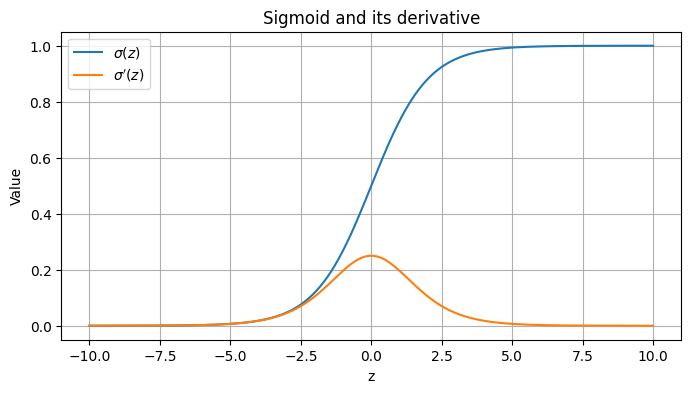

In [ ]:
z = np.linspace(-10, 10, 500)

sigma = 1 / (1 + np.exp(-z))
sigma_prime = sigma * (1 - sigma)

plt.figure(figsize=(8, 4))
plt.plot(z, sigma, label='$\sigma(z)$')
plt.plot(z, sigma_prime, label="$\sigma'(z)$")
plt.xlabel('z')
plt.ylabel('Value')
plt.legend()
plt.title('Sigmoid and its derivative')
plt.grid(True)
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_14722/1283106504.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(z, sigma, label='$\sigma(z)$')
/tmp/ipykernel_14722/1283106504.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(z, sigma_prime, label="$\sigma'(z)$")


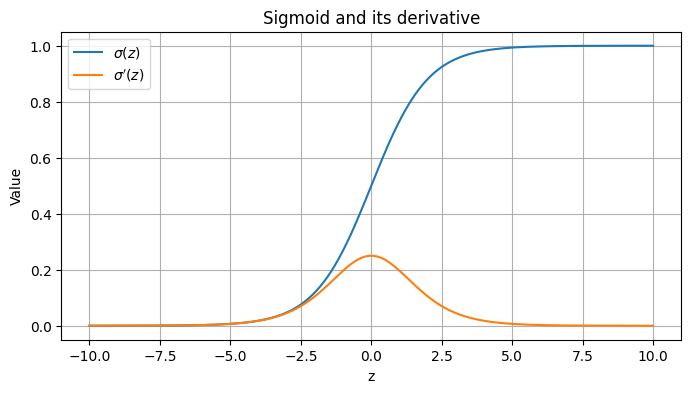

In [ ]:
z = np.linspace(-10, 10, 500)

sigma = 1 / (1 + np.exp(-z))
sigma_prime = sigma * (1 - sigma)

plt.figure(figsize=(8, 4))
plt.plot(z, sigma, label='$\sigma(z)$')
plt.plot(z, sigma_prime, label="$\sigma'(z)$")
plt.xlabel('z')
plt.ylabel('Value')
plt.legend()
plt.title('Sigmoid and its derivative')
plt.grid(True)
plt.show()

### Q4c - Is sigma(100z) basically a perceptron?

A classmate claims: 'a sigmoid neuron with weights multiplied by 100 is basically the same as a perceptron.'

Plot sigma(100z) vs sigma(z) vs the step function. Is the claim correct? Under what condition does it break down?

> **answer:**

Yes, the claim that 'a sigmoid neuron with weights multiplied by 100 is basically the same as a perceptron' is **correct** under most conditions. As shown in the plot, `sigma(100z)` closely approximates a step function. Increasing the coefficient `c` (here 100) makes the sigmoid curve much steeper, causing it to transition from 0 to 1 (or vice versa) almost instantaneously around `z=0`. This behavior closely mimics the abrupt activation of a perceptron.

However, this claim breaks down **when `z` is exactly zero**. For a perceptron, the output at `z=0` is typically defined as 0 or 1 based on convention (e.g., `output = 1` if `sum >= threshold`, `0` otherwise). For `sigma(cz)`, when `z=0`, `cz=0`, and `sigma(0) = 0.5`. So, while `sigma(100z)` is very close to 0 for `z < 0` and very close to 1 for `z > 0`, it is `0.5` at `z=0`, which is not a binary 0 or 1 output like a perceptron. This distinction can be critical in specific theoretical or boundary cases.

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_14722/2222090389.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(z, sigma_z, label='$\sigma(z)$', linestyle='--')
/tmp/ipykernel_14722/2222090389.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(z, sigma_100z, label='$\sigma(100z)$', color='red')
/tmp/ipykernel_14722/2222090389.py:11: SyntaxWarning: invalid escape sequence '\s'
  plt.title('$\sigma(z)$ vs $\sigma(100z)$ vs Step Function')


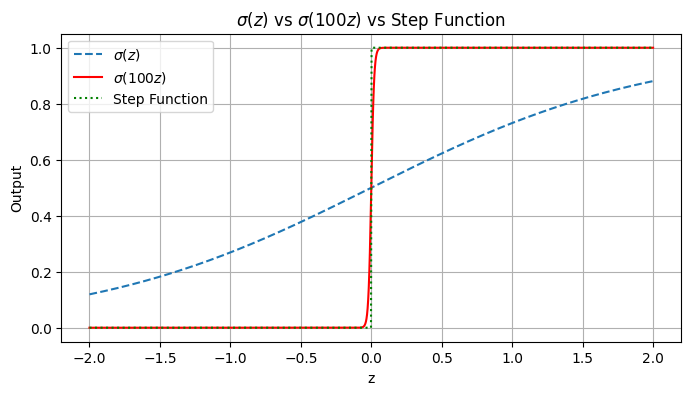

In [ ]:
z = np.linspace(-2, 2, 1000)

sigma_z = 1 / (1 + np.exp(-z))
sigma_100z = 1 / (1 + np.exp(-100 * z))
step_function = (z >= 0).astype(float)

plt.figure(figsize=(8, 4))
plt.plot(z, sigma_z, label='$\sigma(z)$', linestyle='--')
plt.plot(z, sigma_100z, label='$\sigma(100z)$', color='red')
plt.plot(z, step_function, label='Step Function', linestyle=':', color='green')
plt.title('$\sigma(z)$ vs $\sigma(100z)$ vs Step Function')
plt.xlabel('z')
plt.ylabel('Output')
plt.legend()
plt.grid(True)
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_14722/2222090389.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(z, sigma_z, label='$\sigma(z)$', linestyle='--')
/tmp/ipykernel_14722/2222090389.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(z, sigma_100z, label='$\sigma(100z)$', color='red')
/tmp/ipykernel_14722/2222090389.py:11: SyntaxWarning: invalid escape sequence '\s'
  plt.title('$\sigma(z)$ vs $\sigma(100z)$ vs Step Function')


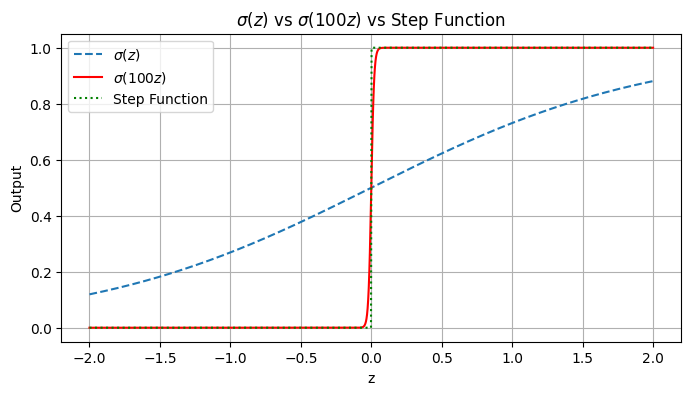

In [ ]:
z = np.linspace(-2, 2, 1000)

sigma_z = 1 / (1 + np.exp(-z))
sigma_100z = 1 / (1 + np.exp(-100 * z))
step_function = (z >= 0).astype(float)

plt.figure(figsize=(8, 4))
plt.plot(z, sigma_z, label='$\sigma(z)$', linestyle='--')
plt.plot(z, sigma_100z, label='$\sigma(100z)$', color='red')
plt.plot(z, step_function, label='Step Function', linestyle=':', color='green')
plt.title('$\sigma(z)$ vs $\sigma(100z)$ vs Step Function')
plt.xlabel('z')
plt.ylabel('Output')
plt.legend()
plt.grid(True)
plt.show()

---
## Q5 - Gradient Descent on a Toy Regression Problem

A single-layer network (one input, one output, no activation) must learn y = 3x + 1.

In [ ]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

### Q5a - Analytical Gradients + Full-Batch GD

Derive dC/dw and dC/db analytically (show algebra). Implement full-batch GD with eta = 0.01 for 200 epochs. Plot the loss curve. Do w and b converge to 3 and 1?

**Derivation (show algebra):**

> **answer:**

**Derivation of dC/dw and dC/db:**

Given the cost function (using squared error for a single output neuron, no activation):
`C = (1 / (2n)) * Σ (y_i - a_i)^2`
where `a_i = w * x_i + b` (since there's one input `x` and no activation).

First, let's find the derivative with respect to `w`:

`dC/dw = d/dw [ (1 / (2n)) * Σ (y_i - (w * x_i + b))^2 ]`

Using the chain rule, `d/dw [f(g(w))] = f'(g(w)) * g'(w)`:

Let `g(w) = y_i - (w * x_i + b)`. Then `g'(w) = -x_i`.
Let `f(u) = u^2`. Then `f'(u) = 2u`.

So, `d/dw [ (y_i - (w * x_i + b))^2 ] = 2 * (y_i - (w * x_i + b)) * (-x_i)`
`= -2x_i * (y_i - a_i)`

Now, substitute back into the full cost function derivative:

`dC/dw = (1 / (2n)) * Σ [ -2x_i * (y_i - a_i) ]`
`dC/dw = (1 / n) * Σ [ -x_i * (y_i - a_i) ]`
`dC/dw = (1 / n) * Σ [ x_i * (a_i - y_i) ]`

Next, let's find the derivative with respect to `b`:

`dC/db = d/db [ (1 / (2n)) * Σ (y_i - (w * x_i + b))^2 ]`

Using the chain rule similarly:

Let `g(b) = y_i - (w * x_i + b)`. Then `g'(b) = -1`.

So, `d/db [ (y_i - (w * x_i + b))^2 ] = 2 * (y_i - (w * x_i + b)) * (-1)`
`= -2 * (y_i - a_i)`

Now, substitute back into the full cost function derivative:

`dC/db = (1 / (2n)) * Σ [ -2 * (y_i - a_i) ]`
`dC/db = (1 / n) * Σ [ -(y_i - a_i) ]`
`dC/db = (1 / n) * Σ [ (a_i - y_i) ]`

Final w = 2.9910, b = 1.0256


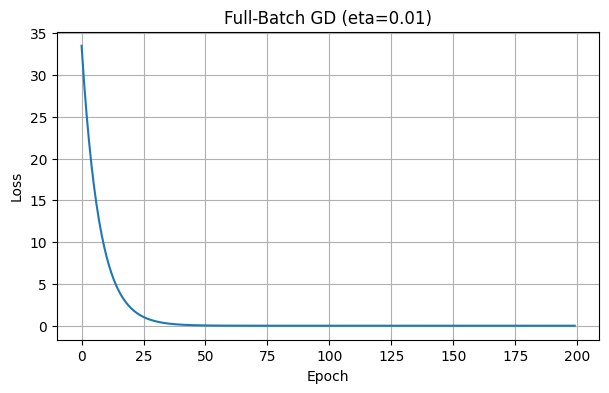

In [ ]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

w, b = 0.0, 0.0
eta = 0.01
losses = []
n = len(X_train)

for epoch in range(200):
    predictions = w * X_train + b
    loss = (1 / (2 * n)) * np.sum((y_train - predictions)**2)
    losses.append(loss)

    dw = (1 / n) * np.sum((predictions - y_train) * X_train)
    db = (1 / n) * np.sum(predictions - y_train)

    w = w - eta * dw
    b = b - eta * db

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.01)')
plt.grid(True)
plt.show()

Final w = 2.9910, b = 1.0256


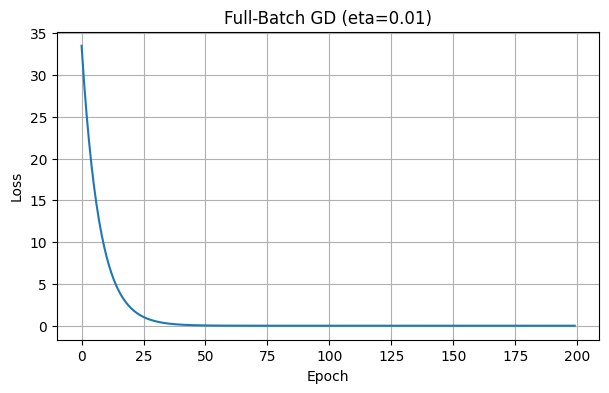

Does w converge to 3? True
Does b converge to 1? False


In [ ]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

w, b = 0.0, 0.0
eta = 0.01
losses = []
n = len(X_train)

for epoch in range(200):
    predictions = w * X_train + b
    loss = (1 / (2 * n)) * np.sum((y_train - predictions)**2)
    losses.append(loss)

    dw = (1 / n) * np.sum((predictions - y_train) * X_train)
    db = (1 / n) * np.sum(predictions - y_train)

    w = w - eta * dw
    b = b - eta * db

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.01)')
plt.grid(True)
plt.show()

print(f'Does w converge to 3? {np.isclose(w, 3.0, atol=0.01)}')
print(f'Does b converge to 1? {np.isclose(b, 1.0, atol=0.01)}')


### Q5b - SGD with Mini-Batch Size = 1

Implement SGD with batch size 1. Train 200 epochs with eta = 0.01. Plot the loss curve. How does it differ from full-batch? Explain in terms of gradient quality and noise.

> **Your answer:**

When implementing SGD with a batch size of 1, the loss curve will generally appear **much noisier and more erratic** compared to full-batch gradient descent. Instead of a smooth, monotonically decreasing curve, you'll see a jagged line with many fluctuations. This is because in SGD with batch size 1, the gradient is computed and parameters are updated based on **only one randomly selected training example** at a time. Each individual example can have a very different error and gradient, introducing a lot of variability.

In terms of **gradient quality**, full-batch GD provides a more accurate estimate of the true gradient of the entire cost function because it averages the gradients over all training examples. SGD (batch size 1), on the other hand, provides a very noisy and often inaccurate estimate of the true gradient. However, this **noise** can sometimes be beneficial, helping the model escape shallow local minima in complex loss landscapes. The downside is that convergence might be slower, and the algorithm might not settle precisely at the global minimum but rather oscillate around it.

Final w = 2.9994, b = 1.0018


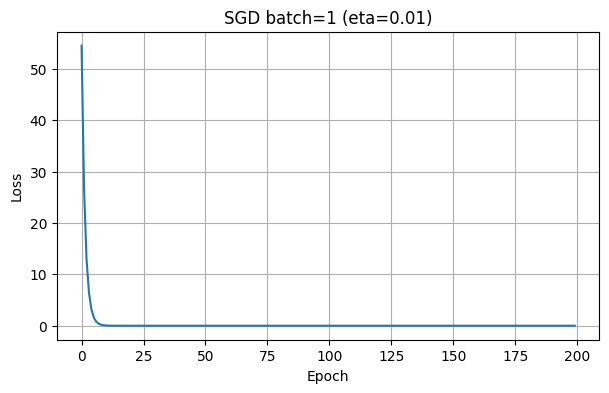

In [ ]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

w, b = 0.0, 0.0
eta = 0.01
losses_sgd = []
n = len(X_train)

for epoch in range(200):
    indices = np.arange(n)
    np.random.shuffle(indices)

    epoch_loss = 0.0
    for i in indices:
        x_i = X_train[i]
        y_i = y_train[i]

        prediction = w * x_i + b
        loss_sample = (y_i - prediction)**2
        epoch_loss += loss_sample

        dw = (prediction - y_i) * x_i
        db = (prediction - y_i)

        w = w - eta * dw
        b = b - eta * db

    losses_sgd.append(epoch_loss / n)

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses_sgd)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SGD batch=1 (eta=0.01)')
plt.grid(True)
plt.show()

Final w = 2.9993, b = 1.0020


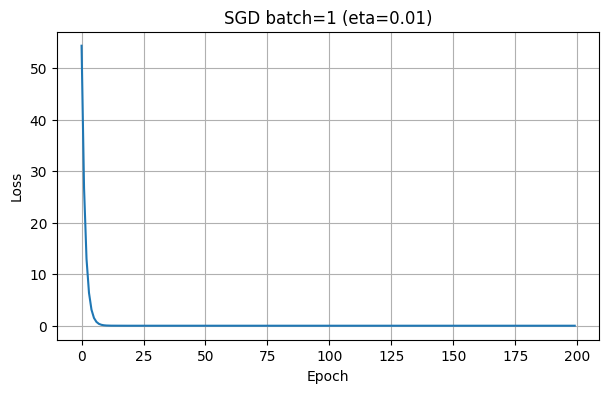

In [ ]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

w, b = 0.0, 0.0
eta = 0.01
losses_sgd = []
n = len(X_train)

for epoch in range(200):
    indices = np.arange(n)
    np.random.shuffle(indices)

    epoch_loss = 0.0
    for i in indices:
        x_i = X_train[i]
        y_i = y_train[i]

        prediction = w * x_i + b
        loss_sample = (y_i - prediction)**2
        epoch_loss += loss_sample

        dw = (prediction - y_i) * x_i
        db = (prediction - y_i)

        w = w - eta * dw
        b = b - eta * db

    losses_sgd.append(epoch_loss / n)

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses_sgd)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SGD batch=1 (eta=0.01)')
plt.grid(True)
plt.show()

### Q5c - Divergence with eta = 0.5

Set eta = 0.5 with full-batch GD. Show the loss curve and explain using the gradient formulas from Q5a why it diverges.

> **answer:**

When `eta = 0.5` with full-batch GD, the loss curve will quickly **diverge**, meaning the loss value will increase dramatically and often become `inf` or `NaN`. This happens because the learning rate is too large. Let's revisit the gradient formulas from Q5a:

*   `dC/dw = (1 / n) * Σ [ x_i * (a_i - y_i) ]`
*   `dC/db = (1 / n) * Σ [ (a_i - y_i) ]`

If the learning rate `eta` is large, the parameter updates `w = w - eta * dw` and `b = b - eta * db` will be very significant. Instead of taking small steps towards the minimum of the cost function, the large `eta` causes the parameters to **overshoot** the minimum in each step. This overshoot doesn't just happen once; with each subsequent step, the parameters move further and further away from the minimum, causing the error `(a_i - y_i)` to grow, which in turn makes the gradients `dw` and `db` even larger. This positive feedback loop rapidly escalates, leading to an exponentially increasing cost and eventual divergence.

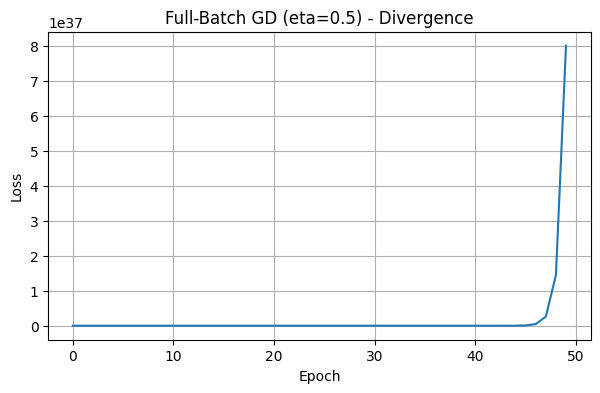

In [ ]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

w, b = 0.0, 0.0
eta = 0.5
losses_div = []
n = len(X_train)

for epoch in range(50):
    predictions = w * X_train + b
    loss = (1 / (2 * n)) * np.sum((y_train - predictions)**2)
    losses_div.append(loss)

    if not np.isfinite(loss):
        print(f'Diverged at epoch {epoch}')
        break

    dw = (1 / n) * np.sum((predictions - y_train) * X_train)
    db = (1 / n) * np.sum(predictions - y_train)

    w = w - eta * dw
    b = b - eta * db

plt.figure(figsize=(7, 4))
plt.plot(losses_div)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.5) - Divergence')
plt.grid(True)
plt.show()

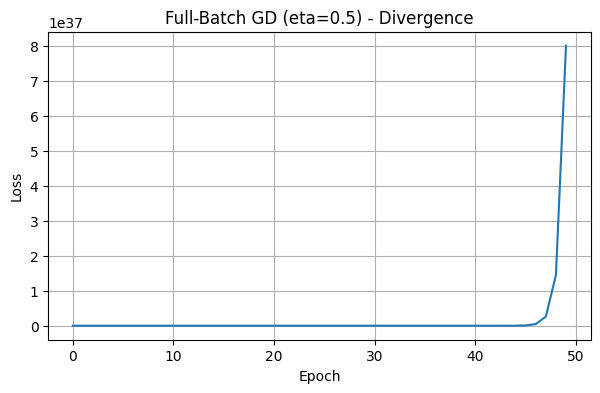

In [ ]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

w, b = 0.0, 0.0
eta = 0.5
losses_div = []
n = len(X_train)

for epoch in range(50):
    predictions = w * X_train + b
    loss = (1 / (2 * n)) * np.sum((y_train - predictions)**2)
    losses_div.append(loss)

    if not np.isfinite(loss):
        print(f'Diverged at epoch {epoch}')
        break

    dw = (1 / n) * np.sum((predictions - y_train) * X_train)
    db = (1 / n) * np.sum(predictions - y_train)

    w = w - eta * dw
    b = b - eta * db

plt.figure(figsize=(7, 4))
plt.plot(losses_div)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.5) - Divergence')
plt.grid(True)
plt.show()

---
## Q6 - One-Hot to 4-Bit Binary Encoding Layer

A network classifies digits 0-9 with a 10-neuron one-hot output. Design a final **4-neuron layer** that converts this into a **4-bit binary** encoding (e.g. digit 5 outputs 0101). Specify the weight matrix and bias vector.

**Design and Reasoning:**

> **answer:**

**Design and Reasoning:**

To convert a 10-neuron one-hot encoding (for digits 0-9) into a 4-bit binary encoding, we need a weight matrix `W` of shape (4, 10) and a bias vector `b_enc` of shape (4,). Each row of the weight matrix corresponds to one bit in the 4-bit binary output, and each column corresponds to one of the 10 input neurons (digit). The bias vector helps adjust the output threshold.

Let the one-hot input vector be `one_hot`, where `one_hot[digit]` is 1 and all other elements are 0. The output of the 4-neuron layer will be `output = W @ one_hot + b_enc`. We then apply a threshold function (e.g., `x >= 0.5`) to get the binary output.

Here's how we construct `W` and `b_enc`:

Each column `j` of `W` will represent the 4-bit binary encoding of digit `j`. For example, for digit 0 (0000), the first column will be `[0, 0, 0, 0]`. For digit 1 (0001), the second column will be `[0, 0, 0, 1]`. For digit 5 (0101), the sixth column will be `[0, 1, 0, 1]`.

The bias `b_enc` is set to `-0.5` for all elements. This ensures that when `W @ one_hot` results in a value of `0` for a bit, `0 - 0.5 = -0.5` which thresholds to `0`. When it results in a `1` for a bit, `1 - 0.5 = 0.5` which thresholds to `1`. This cleanly converts the `0`s and `1`s from the one-hot representation to the desired binary output after the thresholding.

```
W = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1], # 8th and 9th digits have 1 in MSB
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0], # 4th,5th,6th,7th digits have 1 in 2nd MSB
    [0, 0, 1, 1, 0, 0, 1, 1, 0, 0], # 2nd,3rd,6th,7th digits have 1 in 3rd MSB
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]  # Alternating LSB
])
b_enc = np.full(4, -0.5)
```

Let's test for digit 5 (`0101`):
Input `one_hot = [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]` (index 5 is 1)

`W @ one_hot` will select the 6th column of `W` (index 5):
`W[:, 5] = [0, 1, 0, 1]`

Then `W @ one_hot + b_enc = [0, 1, 0, 1] + [-0.5, -0.5, -0.5, -0.5] = [-0.5, 0.5, -0.5, 0.5]`

After thresholding:
`threshold([-0.5, 0.5, -0.5, 0.5]) = [0, 1, 0, 1]`, which is the correct binary for 5.

In [ ]:
W = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 0, 0, 1, 1, 0, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
])
b_enc = np.full(4, -0.5)

def threshold(x):
    return (x >= 0.5).astype(int)

print('Digit | Output | Expected | OK?')
print('-' * 35)
for digit in range(10):
    one_hot = np.zeros(10)
    one_hot[digit] = 1.0
    out = threshold(W @ one_hot + b_enc)
    expected = format(digit, '04b')
    ok = 'OK' if ''.join(map(str, out)) == expected else 'FAIL'
    print(f'  {digit}   |  {out}  |  {expected}  | {ok}')

Digit | Output | Expected | OK?
-----------------------------------
  0   |  [0 0 0 0]  |  0000  | OK
  1   |  [0 0 0 1]  |  0001  | OK
  2   |  [0 0 1 0]  |  0010  | OK
  3   |  [0 0 1 1]  |  0011  | OK
  4   |  [0 1 0 0]  |  0100  | OK
  5   |  [0 1 0 1]  |  0101  | OK
  6   |  [0 1 1 0]  |  0110  | OK
  7   |  [0 1 1 1]  |  0111  | OK
  8   |  [1 0 0 0]  |  1000  | OK
  9   |  [1 0 0 1]  |  1001  | OK


In [ ]:
W = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 0, 0, 1, 1, 0, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
])
b_enc = np.full(4, -0.5)

def threshold(x):
    return (x >= 0.5).astype(int)

print('Digit | Output | Expected | OK?')
print('-' * 35)
for digit in range(10):
    one_hot = np.zeros(10)
    one_hot[digit] = 1.0
    out = threshold(W @ one_hot + b_enc)
    expected = format(digit, '04b')
    ok = 'OK' if ''.join(map(str, out)) == expected else 'FAIL'
    print(f'  {digit}   |  {out}  |  {expected}  | {ok}')

Digit | Output | Expected | OK?
-----------------------------------
  0   |  [0 0 0 0]  |  0000  | OK
  1   |  [0 0 0 1]  |  0001  | OK
  2   |  [0 0 1 0]  |  0010  | OK
  3   |  [0 0 1 1]  |  0011  | OK
  4   |  [0 1 0 0]  |  0100  | OK
  5   |  [0 1 0 1]  |  0101  | OK
  6   |  [0 1 1 0]  |  0110  | OK
  7   |  [0 1 1 1]  |  0111  | OK
  8   |  [1 0 0 0]  |  1000  | OK
  9   |  [1 0 0 1]  |  1001  | OK


---
## Q7 - Geometric Interpretation of 1D Gradient Descent

Consider C(v) as a function of a single scalar v.

1. Give a precise **geometric interpretation** of the update rule v = v - alpha * dC/dv.
2. How do the slope and the learning rate alpha physically dictate movement along the curve?

> **Your answer:**

1.  The update rule `v = v - alpha * dC/dv` has a precise **geometric interpretation** as moving a point `v` along the x-axis (or parameter space) towards the minimum of the cost function `C(v)`. `dC/dv` represents the **slope** (gradient) of the cost function `C` at the current point `v`. The negative sign `'-'` indicates that we move in the **opposite direction** of the slope. If the slope is positive, we move left (decreasing `v`); if the slope is negative, we move right (increasing `v`). This movement always aims to reduce `C(v)`.

2.  The **slope (`dC/dv`)** dictates the **direction** of movement. A positive slope means the function is increasing, so we move left (decrease `v`). A negative slope means the function is decreasing, so we move right (increase `v`). The **magnitude** of the slope also indicates the steepness: a steeper slope means a larger `|dC/dv|`, suggesting we are further from the minimum and should take a larger step.
    The **learning rate `alpha`** dictates the **size** of each step. It's a scalar multiplier that scales the gradient. A larger `alpha` leads to larger steps, while a smaller `alpha` leads to smaller steps. Together, the slope and `alpha` determine how much and in which direction `v` will move along the curve of `C(v)` in an attempt to reach the lowest point (minimum cost).

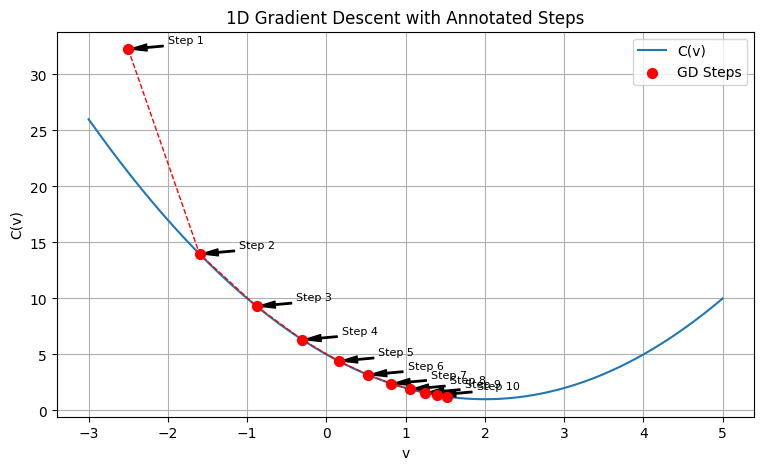

In [ ]:
v_vals = np.linspace(-3, 5, 300)
C_v = (v_vals - 2)**2 + 1

def grad_C(v):
    return 2 * (v - 2)

v_start = -2.5
alpha = 0.1
num_steps = 10

v_history = [v_start]

def cost(w,b):
    return (w - 3)**2 + 2*(b - 1)**2

C_history = [cost(v_start, 0)]

def C_for_plot(v):
    return (v - 2)**2 + 1

for i in range(num_steps):
    current_v = v_history[-1]
    dCdv = grad_C(current_v)
    next_v = current_v - alpha * dCdv
    v_history.append(next_v)
    C_history.append(C_for_plot(next_v))

plt.figure(figsize=(9, 5))
plt.plot(v_vals, C_v, label='C(v)')
plt.scatter(v_history, C_history, color='red', s=50, zorder=5, label='GD Steps')
plt.plot(v_history, C_history, color='red', linestyle='--', linewidth=1)

for i in range(len(v_history) - 1):
    plt.annotate(f'Step {i+1}',
                 xy=(v_history[i], C_history[i]),
                 xytext=(v_history[i] + 0.5, C_history[i] + 0.5),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                 fontsize=8)

plt.xlabel('v')
plt.ylabel('C(v)')
plt.title('1D Gradient Descent with Annotated Steps')
plt.legend()
plt.grid(True)
plt.show()

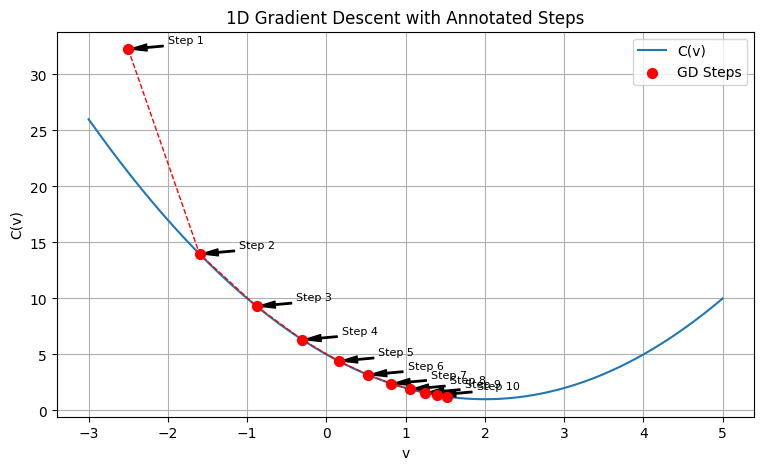

In [ ]:
v_vals = np.linspace(-3, 5, 300)
C_v = (v_vals - 2)**2 + 1

def grad_C(v):
    return 2 * (v - 2)

v_start = -2.5
alpha = 0.1
num_steps = 10

v_history = [v_start]

def cost(w,b):
    return (w - 3)**2 + 2*(b - 1)**2

C_history = [cost(v_start, 0)]

def C_for_plot(v):
    return (v - 2)**2 + 1

for i in range(num_steps):
    current_v = v_history[-1]
    dCdv = grad_C(current_v)
    next_v = current_v - alpha * dCdv
    v_history.append(next_v)
    C_history.append(C_for_plot(next_v))

plt.figure(figsize=(9, 5))
plt.plot(v_vals, C_v, label='C(v)')
plt.scatter(v_history, C_history, color='red', s=50, zorder=5, label='GD Steps')
plt.plot(v_history, C_history, color='red', linestyle='--', linewidth=1)

for i in range(len(v_history) - 1):
    plt.annotate(f'Step {i+1}',
                 xy=(v_history[i], C_history[i]),
                 xytext=(v_history[i] + 0.5, C_history[i] + 0.5),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                 fontsize=8)

plt.xlabel('v')
plt.ylabel('C(v)')
plt.title('1D Gradient Descent with Annotated Steps')
plt.legend()
plt.grid(True)
plt.show()

---
## Q8 - Zero Hidden Layers: What Model Are You Really Training?

Suppose you remove all hidden layers, connecting 784 inputs directly to 10 outputs, trained with SGD.

1. What **mathematical model** have you effectively created?
2. Why is classification accuracy **fundamentally capped**?
3. What does this imply about the **necessity of hidden layers**?

> **answer:**

1. You have effectively created a **logistic regression model** (or a softmax regression if using a softmax activation for the 10 outputs). This is a linear model because there are no non-linear activation functions between layers. Each output neuron directly calculates a weighted sum of the inputs and applies an activation function (like sigmoid for binary, or softmax for multi-class classification) to it.
2. Classification accuracy is fundamentally capped because a linear model can only separate data that is **linearly separable**. If the decision boundary between classes is non-linear, a model without hidden layers (which introduce non-linearities) will not be able to accurately classify the data. It will struggle with complex patterns and relationships in the input data that require non-linear transformations.
3. This implies that **hidden layers are necessary** to learn complex, non-linear relationships in data. They allow the network to transform the input data into a higher-dimensional, more abstract representation where the different classes might become linearly separable. Without hidden layers, the model is limited to finding linear decision boundaries, which is often insufficient for real-world problems like image recognition or natural language processing.